In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from dateutil import parser


Month4:
Week 1:
Assignment: Cafe Sales Data Cleaning, Analysis & Insights
Problem Statement
You have been provided with a messy cafe sales dataset containing transaction records from a fictional cafe chain. The dataset includes customer purchases, prices, payment information, and transaction dates, but the data contains errors, missing values, inconsistent categories, and invalid entries.
Your task is to clean the dataset, perform exploratory data analysis (EDA), create visualizations, and present insights that could help the cafe understand its sales performance, customer behavior, and operational issues.

Dataset Description
The dataset contains the following columns:

Transaction ID – A unique identifier for each transaction.
Item – Name of the purchased item.
Quantity – Number of units bought.
Price Per Unit – Cost of a single unit.
Total Spent – Total transaction amount.
Payment Method – Payment type used (may contain nulls or unknowns).
Location – Where the transaction occurred (e.g., In-store, Takeaway).
Transaction Date – Date of transaction (may include errors).

Dataset:
Download the  Cafe Sales - Dirty Data dataset from Kaggle.
Questions / Tasks

1. Data Cleaning
Clean the dataset thoroughly to make it ready for analysis. Your cleaning process should include:
a. Handling Missing Values
b. Correcting Invalid Entries
Use the following rules consistently:

"ERROR" in numeric fields (Quantity, Price Per Unit, Total Spent)
 Replace with NaN.


"ERROR" in categorical fields (Item, Payment Method, Location)
 Replace with "Unknown".


"UNKNOWN" in any categorical field
 Standardize to "Unknown" (proper casing).


c. Fixing Numeric Inconsistencies
Convert Quantity, Price Per Unit, and Total Spent to numeric types.


Identify rows where:
 Quantity × Price Per Unit not equal to Total Spent
 Correct the total if possible or flag the row for review.


d. Standardizing Categories
Ensure item names, payment methods, and locations use consistent spelling and casing.


e. Ensuring Proper Data Types
Convert dates to valid datetime format.


Convert numeric fields to int or float as appropriate.

2. Exploratory Data Analysis (EDA)
After cleaning the dataset, explore the following:
a. Top-selling items: Which products are purchased the most?
b. Revenue analysis:
Total revenue


Revenue by item category


Revenue by location
c. Customer behavior trends:


Most common payment method


Average spend per transaction
d. Time-based trends:


Monthly sales trends


Busiest months and slowest months


Day-of-week sales performance (optional)


Summaries should be clear and insight-driven.

3. Data Visualization
Create at least 5 visualizations, such as:
Bar chart: Top 5 items by sales volume


Pie chart or bar chart: Distribution of payment methods


Line chart: Monthly revenue trend


Histogram: Distribution of transaction amounts


Bar chart: Revenue by location (In-store vs Takeaway)


Each visualization should be labelled clearly with a title and axis descriptions.

4. Insight Summary
Write a concise business-focused summary that highlights:
Sales performance trends


Customer purchasing patterns


Operational issues discovered due to dirty data


Any recommendations for improving data quality and café operations


Your insight summary should read like something you'd present to management, professional, persuasive, and actionable.

Expected Deliverables
1. Cleaned dataset (CSV or Excel).

2. Jupyter Notebook containing:


Data import


Cleaning steps


EDA


Visualizations


Insight summary


3. A short written report summarizing your approach and key findings.







In [2]:
#Load the dataset csv file from Vscode to jupyter notebook

df = pd.read_csv("dirty_cafe_sales.csv")

df


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4,1,ERROR,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,4/27/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,6/11/2023
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2,4,NaN,UNKNOWN,8/30/2023
9996,TXN_9659401,NaN,3,NaN,3,Digital Wallet,NaN,6/2/2023
9997,TXN_5255387,Coffee,4,2,8,Digital Wallet,NaN,3/2/2023
9998,TXN_7695629,Cookie,3,NaN,3,Digital Wallet,NaN,12/2/2023


In [3]:
# Explore and data cleaning   .info()
#check the info of the dataset 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 1.0 MB


In [4]:
#check missing value  => .isnull()

# To calculate the total missing values in the dataset  =>  .isnull().sum()

df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [5]:
#Shape will let you known the numbers of rows and colunms you have in the dataset
#Shape(row, colunm)  .shape

df.shape

(10000, 8)

In [6]:
#get the dataset colunms  => .columns

df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [7]:
#inspect unique values in colunms
#pandas represents none value as nan (NaN) and blank space as nan (NaN)

print("TRANSACTION ID", df["Transaction ID"].unique())
print("ITEM", df["Item"].unique())
print("QUANTITY", df["Quantity"].unique())
print("PRICE PER UNIT", df["Price Per Unit"].unique())
print("TOTAL SPENT", df["Total Spent"].unique())
print("PAYMENT METHOD", df["Payment Method"].unique())
print("LOCATION", df["Location"].unique())
print("TRANSACTION DATE", df["Transaction Date"].unique())

TRANSACTION ID <ArrowStringArray>
['TXN_1961373', 'TXN_4977031', 'TXN_4271903', 'TXN_7034554', 'TXN_3160411',
 'TXN_2602893', 'TXN_4433211', 'TXN_6699534', 'TXN_4717867', 'TXN_2064365',
 ...
 'TXN_1538510', 'TXN_3897619', 'TXN_2739140', 'TXN_4766549', 'TXN_7851634',
 'TXN_7672686', 'TXN_9659401', 'TXN_5255387', 'TXN_7695629', 'TXN_6170729']
Length: 10000, dtype: str
ITEM <ArrowStringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',  'UNKNOWN',
 'Sandwich',        nan,    'ERROR',    'Juice',      'Tea']
Length: 11, dtype: str
QUANTITY <ArrowStringArray>
['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan]
Length: 8, dtype: str
PRICE PER UNIT <ArrowStringArray>
['2', '3', '1', '5', '4', '1.5', nan, 'ERROR', 'UNKNOWN']
Length: 9, dtype: str
TOTAL SPENT <ArrowStringArray>
[      '4',      '12',   'ERROR',      '10',      '20',       '9',      '16',
      '15',      '25',       '8',       '5',       '3',       '6',       nan,
 'UNKNOWN',       '2',       '1',     '7.5',    

In [8]:
# 1. Data Cleaning
# Clean the dataset thoroughly to make it ready for analysis. Your cleaning process should include:
# a. Handling Missing Values
# replace missing value with NaN

df.replace("", np.nan, inplace=True)

df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4,1,ERROR,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,4/27/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,6/11/2023
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2,4,NaN,UNKNOWN,8/30/2023
9996,TXN_9659401,NaN,3,NaN,3,Digital Wallet,NaN,6/2/2023
9997,TXN_5255387,Coffee,4,2,8,Digital Wallet,NaN,3/2/2023
9998,TXN_7695629,Cookie,3,NaN,3,Digital Wallet,NaN,12/2/2023


In [9]:
# b. Correcting Invalid Entries
# Use the following rules consistently:

# "ERROR" in numeric fields (Quantity, Price Per Unit, Total Spent)
#  Replace with NaN.


numeric_columns = ["Quantity", "Price Per Unit", "Total Spent"]

for col in numeric_columns:
    
     df[col] = df[col].replace("ERROR", np.nan)
    
df[col].to_list()

df[col]

#df

# Question: why did it display only Total spent value instead of displaying all the numeric colunms value)

0         4
1        12
2       NaN
3        10
4         4
       ... 
9995      4
9996      3
9997      8
9998      3
9999     12
Name: Total Spent, Length: 10000, dtype: str

In [10]:
# "ERROR" in numeric fields (Quantity)
#  Replace with NaN.

df["Quantity"] = df["Quantity"].replace("ERROR", np.nan)

df["Quantity"].to_list()

df["Quantity"].head(60)

0           2
1           4
2           4
3           2
4           2
5           5
6           3
7           4
8           5
9           5
10          5
11          2
12          2
13          5
14          2
15          3
16          1
17          2
18          5
19          4
20        NaN
21          4
22          3
23          2
24          5
25          3
26          5
27          4
28          5
29          4
30          5
31          2
32          4
33          5
34          2
35          1
36          4
37          2
38          4
39          4
40          3
41          4
42          2
43          4
44          2
45          3
46          4
47          5
48          5
49          3
50          5
51          5
52          5
53          3
54          5
55        NaN
56          5
57    UNKNOWN
58          4
59          5
Name: Quantity, dtype: str

In [11]:
# "ERROR" in numeric fields (Price Per Unit)
#  Replace with NaN.

df["Price Per Unit"] = df["Price Per Unit"].replace("ERROR", np.nan)

df["Price Per Unit"].to_list()

df["Price Per Unit"].head(60)

0       2
1       3
2       1
3       5
4       2
5       4
6       3
7       4
8       3
9       4
10      5
11      4
12      4
13      1
14    1.5
15      5
16      4
17      3
18      3
19      3
20      4
21      4
22      4
23      4
24      4
25      4
26      1
27      3
28      4
29      3
30      2
31      1
32      4
33      1
34      4
35      4
36      3
37      5
38      4
39      2
40      4
41      4
42    1.5
43      3
44      1
45      5
46      3
47      3
48      3
49      3
50      3
51      5
52      5
53      4
54      4
55      1
56    NaN
57      3
58      4
59      3
Name: Price Per Unit, dtype: str

In [12]:
# "ERROR" in numeric fields (Total Spent)
#  Replace with NaN.

df["Total Spent"] = df["Total Spent"].replace("ERROR", np.nan)

df["Total Spent"].to_list()

df["Total Spent"].head(60)

0           4
1          12
2         NaN
3          10
4           4
5          20
6           9
7          16
8          15
9          20
10         25
11          8
12          8
13          5
14          3
15         15
16          4
17          6
18         15
19         12
20         20
21         16
22         12
23          8
24         20
25        NaN
26          5
27         12
28         20
29         12
30         10
31        NaN
32         16
33          5
34          8
35          4
36         12
37         10
38         16
39          8
40         12
41         16
42    UNKNOWN
43         12
44          2
45         15
46         12
47         15
48         15
49          9
50         15
51         25
52         25
53         12
54         20
55          2
56         15
57          3
58         16
59         15
Name: Total Spent, dtype: str

In [13]:
# b. Correcting Invalid Entries
# Use the following rules consistently:

# # "ERROR" in categorical fields (Item, Payment Method, Location)
# #  Replace with "Unknown".

categorical_columns = ["Item", "Payment Method", "Location"]

for col in categorical_columns:
       df[col] = df[col].replace("ERROR", "Unknown")

df[col].head(60)

# #df
# # Question: why did it display only Location value instead of displaying all the categorical fields value)

0     Takeaway
1     In-store
2     In-store
3      UNKNOWN
4     In-store
5          NaN
6     Takeaway
7      UNKNOWN
8     Takeaway
9     In-store
10    Takeaway
11    Takeaway
12    In-store
13    Takeaway
14    In-store
15    In-store
16         NaN
17    In-store
18     Unknown
19    Takeaway
20    In-store
21    Takeaway
22    Takeaway
23         NaN
24    In-store
25     UNKNOWN
26    In-store
27    Takeaway
28         NaN
29    Takeaway
30         NaN
31     Unknown
32    In-store
33         NaN
34    Takeaway
35     UNKNOWN
36    In-store
37    In-store
38    Takeaway
39         NaN
40    In-store
41    Takeaway
42    Takeaway
43    Takeaway
44         NaN
45         NaN
46    In-store
47         NaN
48         NaN
49     Unknown
50    Takeaway
51    Takeaway
52         NaN
53         NaN
54    Takeaway
55    Takeaway
56    Takeaway
57    In-store
58    Takeaway
59    In-store
Name: Location, dtype: str

In [14]:
# "ERROR" in categorical fields (Item)
#  Replace with "Unknown".

df["Item"] = df["Item"].replace("ERROR", np.nan)

df["Item"].to_list()

df["Item"].head

<bound method NDFrame.head of 0         Coffee
1           Cake
2         Cookie
3          Salad
4         Coffee
          ...   
9995      Coffee
9996         NaN
9997      Coffee
9998      Cookie
9999    Sandwich
Name: Item, Length: 10000, dtype: str>

In [15]:
# "ERROR" in categorical fields (Payment Method)
#  Replace with "Unknown".

df["Payment Method"] = df["Payment Method"].replace("ERROR", np.nan)

df["Payment Method"].to_list()

df["Payment Method"].head(60)

0        Credit Card
1               Cash
2        Credit Card
3            UNKNOWN
4     Digital Wallet
5        Credit Card
6            Unknown
7               Cash
8                NaN
9                NaN
10              Cash
11       Credit Card
12              Cash
13               NaN
14               NaN
15       Credit Card
16               NaN
17              Cash
18              Cash
19              Cash
20              Cash
21       Credit Card
22    Digital Wallet
23               NaN
24              Cash
25           UNKNOWN
26       Credit Card
27       Credit Card
28       Credit Card
29    Digital Wallet
30    Digital Wallet
31       Credit Card
32               NaN
33              Cash
34    Digital Wallet
35       Credit Card
36               NaN
37       Credit Card
38               NaN
39           Unknown
40               NaN
41               NaN
42               NaN
43               NaN
44               NaN
45              Cash
46    Digital Wallet
47           

In [16]:
# "ERROR" in categorical fields (Location)
#  Replace with "Unknown".

df["Location"] = df["Location"].replace("ERROR", np.nan)

df["Location"].to_list()

df["Location"].head(60)

0     Takeaway
1     In-store
2     In-store
3      UNKNOWN
4     In-store
5          NaN
6     Takeaway
7      UNKNOWN
8     Takeaway
9     In-store
10    Takeaway
11    Takeaway
12    In-store
13    Takeaway
14    In-store
15    In-store
16         NaN
17    In-store
18     Unknown
19    Takeaway
20    In-store
21    Takeaway
22    Takeaway
23         NaN
24    In-store
25     UNKNOWN
26    In-store
27    Takeaway
28         NaN
29    Takeaway
30         NaN
31     Unknown
32    In-store
33         NaN
34    Takeaway
35     UNKNOWN
36    In-store
37    In-store
38    Takeaway
39         NaN
40    In-store
41    Takeaway
42    Takeaway
43    Takeaway
44         NaN
45         NaN
46    In-store
47         NaN
48         NaN
49     Unknown
50    Takeaway
51    Takeaway
52         NaN
53         NaN
54    Takeaway
55    Takeaway
56    Takeaway
57    In-store
58    Takeaway
59    In-store
Name: Location, dtype: str

In [17]:
# b. Correcting Invalid Entries
# Use the following rules consistently:

# "UNKNOWN" in any categorical field

# Standardize to "Unknown" (proper casing) => in categorical fields (Item, Payment Method, Location)

for col in categorical_columns:
    df[col] = df[col].replace("UNKNOWN", "Unknown")

df[col]

#df

0       Takeaway
1       In-store
2       In-store
3        Unknown
4       In-store
          ...   
9995     Unknown
9996         NaN
9997         NaN
9998         NaN
9999    In-store
Name: Location, Length: 10000, dtype: str

In [18]:
# "UNKNOWN" in any categorical field
# Standardize to "Unknown" (proper casing) => in categorical fields (Item)

df["Item"] = df["Item"].replace("UNKNOWN", "Unknown")

df["Item"].to_list()

df["Item"].head(60)

0       Coffee
1         Cake
2       Cookie
3        Salad
4       Coffee
5     Smoothie
6      Unknown
7     Sandwich
8          NaN
9     Sandwich
10       Salad
11    Sandwich
12    Sandwich
13      Cookie
14     Unknown
15       Salad
16    Sandwich
17       Juice
18        Cake
19       Juice
20    Smoothie
21    Smoothie
22    Sandwich
23    Sandwich
24    Sandwich
25    Smoothie
26      Cookie
27       Juice
28    Smoothie
29        Cake
30         NaN
31     Unknown
32    Smoothie
33     Unknown
34    Smoothie
35    Sandwich
36     Unknown
37       Salad
38    Smoothie
39      Coffee
40    Smoothie
41    Sandwich
42         Tea
43       Juice
44      Cookie
45       Salad
46       Juice
47       Juice
48       Juice
49        Cake
50        Cake
51       Salad
52     Unknown
53    Smoothie
54    Smoothie
55      Cookie
56        Cake
57        Cake
58    Sandwich
59       Juice
Name: Item, dtype: str

In [19]:
# "UNKNOWN" in any categorical field
# Standardize to "Unknown" (proper casing) => in categorical fields (Payment Method)

df["Payment Method"] = df["Payment Method"].replace("UNKNOWN", "Unknown")

df["Payment Method"].to_list()

df["Payment Method"].head(60)

0        Credit Card
1               Cash
2        Credit Card
3            Unknown
4     Digital Wallet
5        Credit Card
6            Unknown
7               Cash
8                NaN
9                NaN
10              Cash
11       Credit Card
12              Cash
13               NaN
14               NaN
15       Credit Card
16               NaN
17              Cash
18              Cash
19              Cash
20              Cash
21       Credit Card
22    Digital Wallet
23               NaN
24              Cash
25           Unknown
26       Credit Card
27       Credit Card
28       Credit Card
29    Digital Wallet
30    Digital Wallet
31       Credit Card
32               NaN
33              Cash
34    Digital Wallet
35       Credit Card
36               NaN
37       Credit Card
38               NaN
39           Unknown
40               NaN
41               NaN
42               NaN
43               NaN
44               NaN
45              Cash
46    Digital Wallet
47           

In [20]:
# "UNKNOWN" in any categorical field
# Standardize to "Unknown" (proper casing) => in categorical fields (Location)

df["Location"] = df["Location"].replace("UNKNOWN", "Unknown")

df["Location"].to_list()

df["Location"].head(60)

0     Takeaway
1     In-store
2     In-store
3      Unknown
4     In-store
5          NaN
6     Takeaway
7      Unknown
8     Takeaway
9     In-store
10    Takeaway
11    Takeaway
12    In-store
13    Takeaway
14    In-store
15    In-store
16         NaN
17    In-store
18     Unknown
19    Takeaway
20    In-store
21    Takeaway
22    Takeaway
23         NaN
24    In-store
25     Unknown
26    In-store
27    Takeaway
28         NaN
29    Takeaway
30         NaN
31     Unknown
32    In-store
33         NaN
34    Takeaway
35     Unknown
36    In-store
37    In-store
38    Takeaway
39         NaN
40    In-store
41    Takeaway
42    Takeaway
43    Takeaway
44         NaN
45         NaN
46    In-store
47         NaN
48         NaN
49     Unknown
50    Takeaway
51    Takeaway
52         NaN
53         NaN
54    Takeaway
55    Takeaway
56    Takeaway
57    In-store
58    Takeaway
59    In-store
Name: Location, dtype: str

In [21]:
#c. Fixing Numeric Inconsistencies
#Convert Quantity, Price Per Unit, and Total Spent to numeric types.

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

df["Quantity"].head(60)

0     2.0
1     4.0
2     4.0
3     2.0
4     2.0
5     5.0
6     3.0
7     4.0
8     5.0
9     5.0
10    5.0
11    2.0
12    2.0
13    5.0
14    2.0
15    3.0
16    1.0
17    2.0
18    5.0
19    4.0
20    NaN
21    4.0
22    3.0
23    2.0
24    5.0
25    3.0
26    5.0
27    4.0
28    5.0
29    4.0
30    5.0
31    2.0
32    4.0
33    5.0
34    2.0
35    1.0
36    4.0
37    2.0
38    4.0
39    4.0
40    3.0
41    4.0
42    2.0
43    4.0
44    2.0
45    3.0
46    4.0
47    5.0
48    5.0
49    3.0
50    5.0
51    5.0
52    5.0
53    3.0
54    5.0
55    NaN
56    5.0
57    NaN
58    4.0
59    5.0
Name: Quantity, dtype: float64

In [22]:
#Convert Price Per Unit to numeric types.

df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")

df["Price Per Unit"].head(60)

0     2.0
1     3.0
2     1.0
3     5.0
4     2.0
5     4.0
6     3.0
7     4.0
8     3.0
9     4.0
10    5.0
11    4.0
12    4.0
13    1.0
14    1.5
15    5.0
16    4.0
17    3.0
18    3.0
19    3.0
20    4.0
21    4.0
22    4.0
23    4.0
24    4.0
25    4.0
26    1.0
27    3.0
28    4.0
29    3.0
30    2.0
31    1.0
32    4.0
33    1.0
34    4.0
35    4.0
36    3.0
37    5.0
38    4.0
39    2.0
40    4.0
41    4.0
42    1.5
43    3.0
44    1.0
45    5.0
46    3.0
47    3.0
48    3.0
49    3.0
50    3.0
51    5.0
52    5.0
53    4.0
54    4.0
55    1.0
56    NaN
57    3.0
58    4.0
59    3.0
Name: Price Per Unit, dtype: float64

In [23]:
#Convert Total Spent to numeric types.

df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")

df["Total Spent"].head(60)

0      4.0
1     12.0
2      NaN
3     10.0
4      4.0
5     20.0
6      9.0
7     16.0
8     15.0
9     20.0
10    25.0
11     8.0
12     8.0
13     5.0
14     3.0
15    15.0
16     4.0
17     6.0
18    15.0
19    12.0
20    20.0
21    16.0
22    12.0
23     8.0
24    20.0
25     NaN
26     5.0
27    12.0
28    20.0
29    12.0
30    10.0
31     NaN
32    16.0
33     5.0
34     8.0
35     4.0
36    12.0
37    10.0
38    16.0
39     8.0
40    12.0
41    16.0
42     NaN
43    12.0
44     2.0
45    15.0
46    12.0
47    15.0
48    15.0
49     9.0
50    15.0
51    25.0
52    25.0
53    12.0
54    20.0
55     2.0
56    15.0
57     3.0
58    16.0
59    15.0
Name: Total Spent, dtype: float64

In [24]:
# inplace=True is a parameter used to modify a data structure (like a DataFrame or Series) directly, rather than creating a new copy and returning it
# Fill missing numeric values before calculating Total spent
# df["Quantity"].fillna(df["Quantity"].median(), inplace=True)

df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())

df["Quantity"].to_list()

[2.0,
 4.0,
 4.0,
 2.0,
 2.0,
 5.0,
 3.0,
 4.0,
 5.0,
 5.0,
 5.0,
 2.0,
 2.0,
 5.0,
 2.0,
 3.0,
 1.0,
 2.0,
 5.0,
 4.0,
 3.0,
 4.0,
 3.0,
 2.0,
 5.0,
 3.0,
 5.0,
 4.0,
 5.0,
 4.0,
 5.0,
 2.0,
 4.0,
 5.0,
 2.0,
 1.0,
 4.0,
 2.0,
 4.0,
 4.0,
 3.0,
 4.0,
 2.0,
 4.0,
 2.0,
 3.0,
 4.0,
 5.0,
 5.0,
 3.0,
 5.0,
 5.0,
 5.0,
 3.0,
 5.0,
 3.0,
 5.0,
 3.0,
 4.0,
 5.0,
 1.0,
 1.0,
 1.0,
 3.0,
 4.0,
 3.0,
 3.0,
 1.0,
 2.0,
 5.0,
 2.0,
 2.0,
 1.0,
 2.0,
 2.0,
 1.0,
 4.0,
 1.0,
 5.0,
 4.0,
 2.0,
 2.0,
 2.0,
 3.0,
 4.0,
 3.0,
 5.0,
 5.0,
 1.0,
 5.0,
 2.0,
 5.0,
 5.0,
 3.0,
 3.0,
 3.0,
 5.0,
 4.0,
 4.0,
 4.0,
 5.0,
 3.0,
 2.0,
 4.0,
 2.0,
 4.0,
 3.0,
 3.0,
 5.0,
 4.0,
 1.0,
 2.0,
 5.0,
 3.0,
 5.0,
 2.0,
 3.0,
 3.0,
 5.0,
 2.0,
 2.0,
 3.0,
 2.0,
 5.0,
 3.0,
 4.0,
 5.0,
 4.0,
 2.0,
 2.0,
 1.0,
 1.0,
 4.0,
 5.0,
 2.0,
 5.0,
 5.0,
 3.0,
 5.0,
 1.0,
 3.0,
 5.0,
 1.0,
 1.0,
 2.0,
 5.0,
 2.0,
 4.0,
 4.0,
 2.0,
 5.0,
 4.0,
 1.0,
 3.0,
 5.0,
 2.0,
 3.0,
 5.0,
 2.0,
 2.0,
 3.0,
 1.0,
 1.0,
 2.0,
 5.0,
 5.0,
 3.0

In [25]:
# inplace=True is a parameter used to modify a data structure (like a DataFrame or Series) directly, rather than creating a new copy and returning it
# Fill missing numeric values before calculating Total spent
#df["Price Per Unit"].fillna(df["Price Per Unit"].median(), inplace=True)

df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Price Per Unit"].median())

df["Price Per Unit"].to_list()

[2.0,
 3.0,
 1.0,
 5.0,
 2.0,
 4.0,
 3.0,
 4.0,
 3.0,
 4.0,
 5.0,
 4.0,
 4.0,
 1.0,
 1.5,
 5.0,
 4.0,
 3.0,
 3.0,
 3.0,
 4.0,
 4.0,
 4.0,
 4.0,
 4.0,
 4.0,
 1.0,
 3.0,
 4.0,
 3.0,
 2.0,
 1.0,
 4.0,
 1.0,
 4.0,
 4.0,
 3.0,
 5.0,
 4.0,
 2.0,
 4.0,
 4.0,
 1.5,
 3.0,
 1.0,
 5.0,
 3.0,
 3.0,
 3.0,
 3.0,
 3.0,
 5.0,
 5.0,
 4.0,
 4.0,
 1.0,
 3.0,
 3.0,
 4.0,
 3.0,
 5.0,
 3.0,
 4.0,
 5.0,
 4.0,
 3.0,
 3.0,
 1.0,
 3.0,
 3.0,
 1.5,
 3.0,
 1.0,
 5.0,
 4.0,
 2.0,
 4.0,
 5.0,
 1.5,
 3.0,
 2.0,
 4.0,
 1.0,
 3.0,
 3.0,
 3.0,
 3.0,
 1.0,
 5.0,
 1.0,
 1.5,
 3.0,
 3.0,
 2.0,
 3.0,
 5.0,
 5.0,
 2.0,
 3.0,
 2.0,
 5.0,
 5.0,
 3.0,
 3.0,
 3.0,
 5.0,
 1.0,
 1.0,
 1.0,
 1.5,
 4.0,
 4.0,
 4.0,
 3.0,
 2.0,
 5.0,
 3.0,
 3.0,
 3.0,
 5.0,
 3.0,
 2.0,
 3.0,
 2.0,
 3.0,
 1.5,
 3.0,
 4.0,
 3.0,
 4.0,
 1.5,
 1.5,
 3.0,
 3.0,
 3.0,
 1.5,
 2.0,
 5.0,
 4.0,
 1.5,
 3.0,
 3.0,
 2.0,
 3.0,
 5.0,
 1.5,
 3.0,
 3.0,
 3.0,
 3.0,
 5.0,
 3.0,
 2.0,
 3.0,
 2.0,
 4.0,
 2.0,
 5.0,
 2.0,
 3.0,
 4.0,
 3.0,
 3.0,
 1.5,
 3.0,
 4.0,
 4.0

In [26]:
#Identify rows where:
# Quantity × Price Per Unit not equal to Total Spent
# Correct the total if possible or flag the row for review.

calculated_total = df["Quantity"] * df["Price Per Unit"]

incorrect_total = df["Total Spent"] != calculated_total

# Correct totals
# .loc is to overwrite incorrect values in the DataFrame.

df.loc[incorrect_total, "Total Spent"] = calculated_total

df.head(60)
df.tail(60)

#Question: how can we list all value in the df bcos df dosen't work with .to_list()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9940,TXN_8273780,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,10/15/2023
9941,TXN_4224427,Juice,4.0,3.0,12.0,Cash,Takeaway,1/23/2023
9942,TXN_5344848,Salad,1.0,5.0,5.0,Digital Wallet,Takeaway,9/27/2023
9943,TXN_6411708,Coffee,4.0,2.0,8.0,Credit Card,In-store,5/20/2023
9944,TXN_7495283,Cake,3.0,3.0,9.0,Credit Card,Takeaway,4/14/2023
9945,TXN_8153550,Cookie,2.0,1.0,2.0,Cash,Takeaway,10/12/2023
9946,TXN_8807600,Unknown,1.0,4.0,4.0,Cash,Takeaway,9/24/2023
9947,TXN_5921442,Smoothie,4.0,4.0,16.0,Cash,Takeaway,2/4/2023
9948,TXN_9496697,Tea,1.0,1.5,1.5,NaN,In-store,9/27/2023
9949,TXN_3130865,Juice,3.0,3.0,9.0,NaN,In-store,UNKNOWN


In [27]:
#d. Standardizing Categories
# Ensure Item, Payment Method, and Location use consistent spelling and casing.

for col in categorical_columns:
     df[col] = df[col].str.strip().str.title()

df.head(60)
df.tail(60)
df[col]

0       Takeaway
1       In-Store
2       In-Store
3        Unknown
4       In-Store
          ...   
9995     Unknown
9996         NaN
9997         NaN
9998         NaN
9999    In-Store
Name: Location, Length: 10000, dtype: str

In [28]:
#d. Standardizing Categories
# Ensure Item use consistent spelling and casing.


df["Item"] = df["Item"].str.strip().str.title()

df["Item"].to_list()

df["Item"].head(60)



0       Coffee
1         Cake
2       Cookie
3        Salad
4       Coffee
5     Smoothie
6      Unknown
7     Sandwich
8          NaN
9     Sandwich
10       Salad
11    Sandwich
12    Sandwich
13      Cookie
14     Unknown
15       Salad
16    Sandwich
17       Juice
18        Cake
19       Juice
20    Smoothie
21    Smoothie
22    Sandwich
23    Sandwich
24    Sandwich
25    Smoothie
26      Cookie
27       Juice
28    Smoothie
29        Cake
30         NaN
31     Unknown
32    Smoothie
33     Unknown
34    Smoothie
35    Sandwich
36     Unknown
37       Salad
38    Smoothie
39      Coffee
40    Smoothie
41    Sandwich
42         Tea
43       Juice
44      Cookie
45       Salad
46       Juice
47       Juice
48       Juice
49        Cake
50        Cake
51       Salad
52     Unknown
53    Smoothie
54    Smoothie
55      Cookie
56        Cake
57        Cake
58    Sandwich
59       Juice
Name: Item, dtype: str

In [29]:
#d. Standardizing Categories
# Ensure Payment Method use consistent spelling and casing.


df["Payment Method"] = df["Payment Method"].str.strip().str.title()

df["Payment Method"].to_list()

df["Payment Method"].head(60)

0        Credit Card
1               Cash
2        Credit Card
3            Unknown
4     Digital Wallet
5        Credit Card
6            Unknown
7               Cash
8                NaN
9                NaN
10              Cash
11       Credit Card
12              Cash
13               NaN
14               NaN
15       Credit Card
16               NaN
17              Cash
18              Cash
19              Cash
20              Cash
21       Credit Card
22    Digital Wallet
23               NaN
24              Cash
25           Unknown
26       Credit Card
27       Credit Card
28       Credit Card
29    Digital Wallet
30    Digital Wallet
31       Credit Card
32               NaN
33              Cash
34    Digital Wallet
35       Credit Card
36               NaN
37       Credit Card
38               NaN
39           Unknown
40               NaN
41               NaN
42               NaN
43               NaN
44               NaN
45              Cash
46    Digital Wallet
47           

In [30]:
#d. Standardizing Categories
# Ensure Locations use consistent spelling and casing.


df["Location"] = df["Location"].str.strip().str.title()

df["Location"].to_list()

df["Location"].head(60)

0     Takeaway
1     In-Store
2     In-Store
3      Unknown
4     In-Store
5          NaN
6     Takeaway
7      Unknown
8     Takeaway
9     In-Store
10    Takeaway
11    Takeaway
12    In-Store
13    Takeaway
14    In-Store
15    In-Store
16         NaN
17    In-Store
18     Unknown
19    Takeaway
20    In-Store
21    Takeaway
22    Takeaway
23         NaN
24    In-Store
25     Unknown
26    In-Store
27    Takeaway
28         NaN
29    Takeaway
30         NaN
31     Unknown
32    In-Store
33         NaN
34    Takeaway
35     Unknown
36    In-Store
37    In-Store
38    Takeaway
39         NaN
40    In-Store
41    Takeaway
42    Takeaway
43    Takeaway
44         NaN
45         NaN
46    In-Store
47         NaN
48         NaN
49     Unknown
50    Takeaway
51    Takeaway
52         NaN
53         NaN
54    Takeaway
55    Takeaway
56    Takeaway
57    In-Store
58    Takeaway
59    In-Store
Name: Location, dtype: str

In [31]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,5/16/2023
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,7/19/2023
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,4/27/2023
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,6/11/2023
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,Unknown,8/30/2023
9996,TXN_9659401,NaN,3.0,3.0,9.0,Digital Wallet,NaN,6/2/2023
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,3/2/2023
9998,TXN_7695629,Cookie,3.0,3.0,9.0,Digital Wallet,NaN,12/2/2023


In [32]:
#e. Ensuring Proper Data Types
# Convert dates to valid datetime format.

# df["Transaction Date"] = pd.to_datetime(
#     df["Transaction Date"],
#     errors="coerce"
# )

# df["Transaction Date"]


def date_parser(date_str):
    try:
        return parser.parse(date_str, dayfirst=True)
    except Exception:
        return pd.NaT
df["Transaction Date"] = df["Transaction Date"].apply(date_parser)

df["Transaction Date"]

0      2023-08-09
1      2023-05-16
2      2023-07-19
3      2023-04-27
4      2023-11-06
          ...    
9995   2023-08-30
9996   2023-02-06
9997   2023-02-03
9998   2023-02-12
9999   2023-07-11
Name: Transaction Date, Length: 10000, dtype: datetime64[us]

In [33]:
#Convert numeric fields Quantity to int or float as appropriate.

df["Quantity"] = (
    df["Quantity"]
    .astype(str)
    .astype(float)
)

df["Quantity"]

0       2.0
1       4.0
2       4.0
3       2.0
4       2.0
       ... 
9995    2.0
9996    3.0
9997    4.0
9998    3.0
9999    3.0
Name: Quantity, Length: 10000, dtype: float64

In [34]:
#Convert numeric fields Price Per Unit to int or float as appropriate.

df["Price Per Unit"] = (
    df["Price Per Unit"]
    .astype(str)
    .astype(float)
)

df["Price Per Unit"]

0       2.0
1       3.0
2       1.0
3       5.0
4       2.0
       ... 
9995    2.0
9996    3.0
9997    2.0
9998    3.0
9999    4.0
Name: Price Per Unit, Length: 10000, dtype: float64

In [35]:
#Convert numeric fields Total Spent to int or float as appropriate.

df["Total Spent"] = (
    df["Total Spent"]
    .astype(str)
    .astype(float)
)

df["Total Spent"]

0        4.0
1       12.0
2        4.0
3       10.0
4        4.0
        ... 
9995     4.0
9996     9.0
9997     8.0
9998     9.0
9999    12.0
Name: Total Spent, Length: 10000, dtype: float64

In [36]:
#save the clean data in csv on vscode

df.to_csv("cleaned_cafe_sales.csv", index=False)

In [37]:
#Load the clean dataset csv file from Vscode to jupyter notebook

df = pd.read_csv("cleaned_cafe_sales.csv")

df
df.head(60)
df.tail(60)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9940,TXN_8273780,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-10-15
9941,TXN_4224427,Juice,4.0,3.0,12.0,Cash,Takeaway,2023-01-23
9942,TXN_5344848,Salad,1.0,5.0,5.0,Digital Wallet,Takeaway,2023-09-27
9943,TXN_6411708,Coffee,4.0,2.0,8.0,Credit Card,In-Store,2023-05-20
9944,TXN_7495283,Cake,3.0,3.0,9.0,Credit Card,Takeaway,2023-04-14
9945,TXN_8153550,Cookie,2.0,1.0,2.0,Cash,Takeaway,2023-12-10
9946,TXN_8807600,Unknown,1.0,4.0,4.0,Cash,Takeaway,2023-09-24
9947,TXN_5921442,Smoothie,4.0,4.0,16.0,Cash,Takeaway,2023-04-02
9948,TXN_9496697,Tea,1.0,1.5,1.5,NaN,In-Store,2023-09-27
9949,TXN_3130865,Juice,3.0,3.0,9.0,NaN,In-Store,NaN


In [38]:
# 2. Exploratory Data Analysis (EDA)
# After cleaning the dataset, explore the following:
# a. Top-selling items: Which products are purchased the most?

top_items = df.groupby("Item")["Quantity"].sum().sort_values(ascending=False)

print(top_items.head(10))


Item
Coffee      3551.0
Juice       3514.0
Salad       3469.0
Cake        3467.0
Sandwich    3428.0
Smoothie    3353.0
Tea         3319.0
Cookie      3249.0
Unknown     1905.0
Name: Quantity, dtype: float64


In [39]:
# b. Revenue analysis:
# Total revenue

total_revenue = df["Total Spent"].sum()

print("Total Revenue:", total_revenue)


Total Revenue: 89481.5


In [40]:
# Revenue by item category

revenue_by_item = df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)

print(revenue_by_item)




Item
Salad       16959.0
Sandwich    13538.0
Smoothie    13218.0
Juice       10542.0
Cake        10401.0
Coffee       7261.0
Unknown      5566.5
Tea          5296.5
Cookie       3651.0
Name: Total Spent, dtype: float64


In [41]:
# Revenue by location
# c. Customer behavior trends:

revenue_by_location = df.groupby("Location")["Total Spent"].sum()

print(revenue_by_location)




Location
In-Store    27223.0
Takeaway    26686.5
Unknown      6087.0
Name: Total Spent, dtype: float64


In [42]:
# Most common payment method

payment_method = df["Payment Method"].value_counts()

print(payment_method)




Payment Method
Digital Wallet    2291
Credit Card       2273
Cash              2258
Unknown            599
Name: count, dtype: int64


In [43]:
# Average spend per transaction

avg_spend = df["Total Spent"].mean()

print("Average Spend:", avg_spend)


Average Spend: 8.94815


In [44]:
# d Time-based trends:

# Monthly sales trends

# df["Month"] = df["Transaction Date"].dt.to_period("M")

# monthly_sales = df.groupby("Month")["Total Spent"].sum()

# print(monthly_sales)



In [45]:

# Busiest months and slowest months


# Day-of-week sales performance (optional)


# Summaries should be clear and insight-driven.


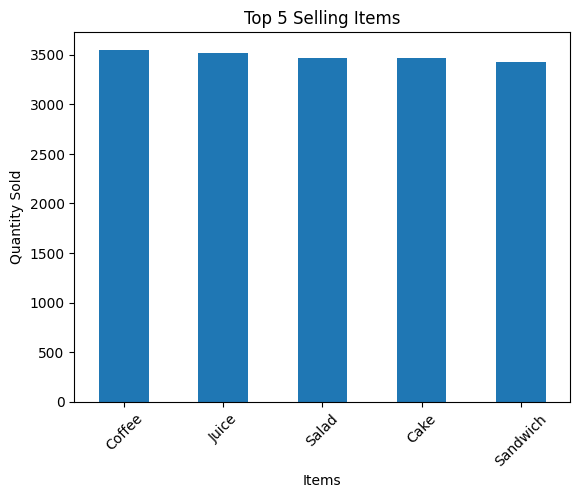

In [46]:
# 3. Data Visualization
# Create at least 5 visualizations, such as:
# Bar chart: Top 5 items by sales volume
# Each visualization should be labelled clearly with a title and axis descriptions.

top5 = top_items.head(5)

top5.plot(kind="bar")
plt.title("Top 5 Selling Items")
plt.xlabel("Items")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()





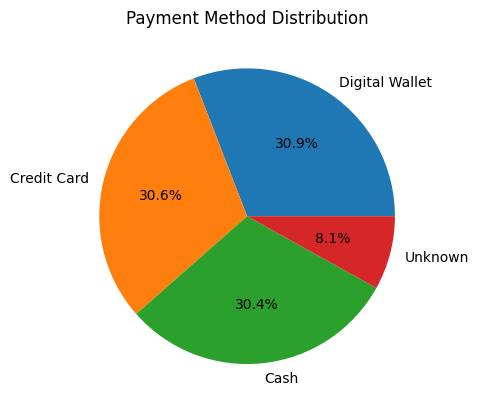

In [47]:
# 3. Data Visualization
# Create at least 5 visualizations, such as:
# Pie chart or bar chart: Distribution of payment methods
# Each visualization should be labelled clearly with a title and axis descriptions.

payment_method.plot(kind="pie", autopct="%1.1f%%")

plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()



In [48]:
# 3. Data Visualization
# Create at least 5 visualizations, such as:
# Line chart: Monthly revenue trend
# Each visualization should be labelled clearly with a title and axis descriptions.

# monthly_sales.plot(kind="line", marker="o")

# plt.title("Monthly Revenue Trend")
# plt.xlabel("Month")
# plt.ylabel("Revenue")
# plt.grid(True)

# plt.show()




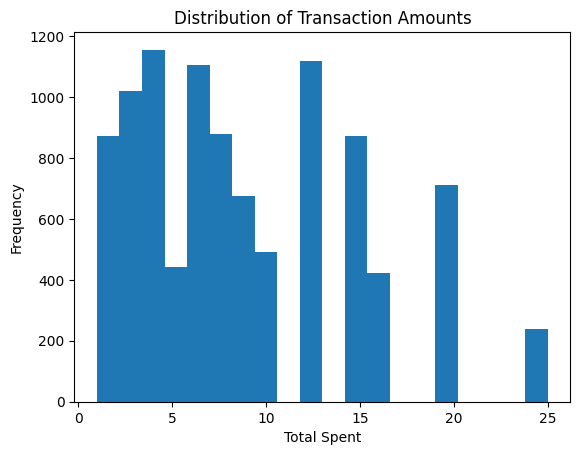

In [49]:
# 3. Data Visualization
# Create at least 5 visualizations, such as:
# Histogram: Distribution of transaction amounts
# Each visualization should be labelled clearly with a title and axis descriptions.

plt.hist(df["Total Spent"], bins=20)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")

plt.show()


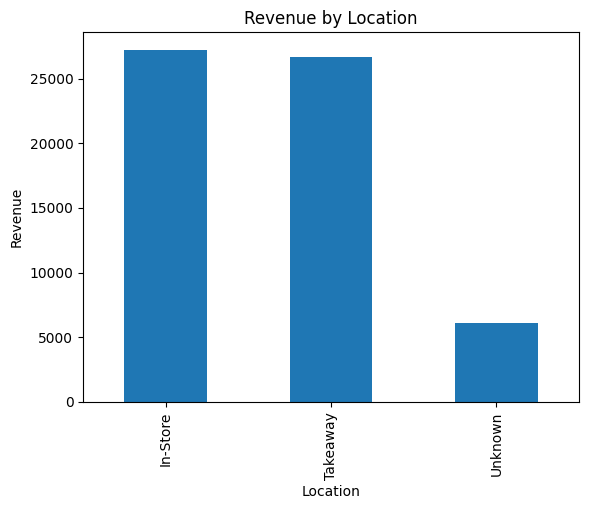

In [50]:
# 3. Data Visualization
# Create at least 5 visualizations, such as:
# Bar chart: Revenue by location (In-store vs Takeaway)
# Each visualization should be labelled clearly with a title and axis descriptions.

revenue_by_location.plot(kind="bar")

plt.title("Revenue by Location")
plt.xlabel("Location")
plt.ylabel("Revenue")

plt.show()


4. Insight Summary

Write a concise business-focused summary that highlights:
Your insight summary should read like something you'd present to management, professional, persuasive, and actionable.

Sales performance trends

1. Certain products contribute significantly more revenue than others.
2. Monthly revenue trends reveal peak and low-performing periods.
3. In-store purchases may generate higher revenue compared to takeaway orders.

4. Insight Summary

Write a concise business-focused summary that highlights:
Your insight summary should read like something you'd present to management, professional, persuasive, and actionable.

Customer purchasing patterns

1. Customers show preference for specific payment methods.
2. Average transaction value helps estimate customer spending behavior.
3. Some items consistently dominate purchase volume.



4. Insight Summary

Write a concise business-focused summary that highlights:
Your insight summary should read like something you'd present to management, professional, persuasive, and actionable.

Operational issues discovered due to dirty data

1. The dataset contained invalid numeric entries such as "ERROR".
2. Several categorical columns had inconsistent labels like "UNKNOWN" and mixed casing.
3. Some transaction totals were mathematically incorrect.
4. Missing dates and duplicate records affected data reliability.


4. Insight Summary

Write a concise business-focused summary that highlights:
Your insight summary should read like something you'd present to management, professional, persuasive, and actionable.

Recommendations for improving data quality and café operations

1. Implement input validation during data entry.
2. Use dropdown menus for categorical fields to avoid spelling inconsistencies.
3. Automatically calculate transaction totals in the sales system.
4. Monitor monthly sales trends to improve inventory planning.
5. Promote high-performing products and optimize low-performing items.

